# **1. Importação das bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Leitura do dataset




In [2]:
df = pd.read_csv('vendas_dataviz_aula2.csv')
df.head()

,data,produto,categoria,estado,canal,vendas,quantidade,preco_unitario,custo,lucro,avaliacao_cliente
0,2024-04-12,Mouse Gamer,Periféricos,RJ,Marketplace,562.26,3,187.42,97.70,269.16,4.6
1,2024-05-01,Headset,Áudio,ES,MarketPlace,1124.08,4,281.02,144.77,545.00,3.8
2,2024-10-03,Teclado Mecânico,Periféricos,SP,Marketplace,2515.73,7,359.39,153.66,1440.11,4.3
3,2024-07-06,Webcam HD,Periféricos,SP,Marketplace,596.76,3,198.92,125.09,221.49,4.3
4,2024-02-24,Smartwatch,Telefonia,RJ,Loja Física,3908.08,4,977.02,666.26,1243.04,4.4


## 3. Anatomia dos dados: DataFrame e Series

### Questão 1
Explique, com base no que foi visto em aula:
1. O que é um **DataFrame**?

R: É uma estrutura de dados bidimensional organizada em linhas e colunas

2. O que é uma **Series**?

R: é uma coluna de um dataFrame que possui um indice associado a cada valor

3. Mostre no código uma coluna isolada do DataFrame.


In [3]:
serie_produto = df['produto']
type(serie_produto), serie_produto.head()

(pandas.core.series.Series,
 0         Mouse Gamer
 1             Headset
 2    Teclado Mecânico
 3           Webcam HD
 4          Smartwatch
 Name: produto, dtype: object)

## 4. Check-up inicial do dataset

Um analista profissional sempre começa verificando o tamanho, a estrutura e a qualidade inicial dos dados.

### Questão 2
Use:
- `df.shape`
- `df.info()`
- `df.dtypes`

Depois responda:
1. Quantas linhas e colunas existem?

R: 450 linhas e 11 colunas

2. Quais colunas parecem numéricas?

R: 5 colunas

3. Há sinais de valores ausentes?

R:Sim, há 450 entradas e 449 valores não nulos, indicando 1 valor nulo

4. Existe alguma coluna com tipo inadequado?

R: A coluna data está incorretamente com tipo object, o mais adequado seria datetime, a coluna vendas também está como object ao invés de float


In [4]:
df.shape

(450, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data               450 non-null    object 
 1   produto            450 non-null    object 
 2   categoria          450 non-null    object 
 3   estado             449 non-null    object 
 4   canal              450 non-null    object 
 5   vendas             450 non-null    object 
 6   quantidade         450 non-null    int64  
 7   preco_unitario     450 non-null    float64
 8   custo              450 non-null    float64
 9   lucro              450 non-null    float64
 10  avaliacao_cliente  448 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 38.8+ KB


In [6]:
df.dtypes

,0
data,object
produto,object
categoria,object
estado,object
canal,object
vendas,object
quantidade,int64
preco_unitario,float64
custo,float64
lucro,float64


## 5. Inspeção de problemas de qualidade

Na aula, vimos que dashboards podem falhar por causa de dados mal preparados.

### Questão 3
Investigue:
- valores nulos
- categorias inconsistentes
- números armazenados como texto
- valores infinitos

Dica:
- `df.isna().sum()`
- `df['canal'].value_counts(dropna=False)`
- `df['estado'].value_counts(dropna=False)`
- `np.isinf(...)`


In [7]:
df.isna().sum()

,0
data,0
produto,0
categoria,0
estado,1
canal,0
vendas,0
quantidade,0
preco_unitario,0
custo,0
lucro,0


In [8]:
df['canal'].value_counts(dropna=False)

,count
canal,
Marketplace,152
Online,148
Loja Física,147
MarketPlace,1
online,1
ONLINE,1


In [9]:
df['estado'].value_counts(dropna=False)

,count
estado,
ES,62
SP,52
BA,52
GO,49
PE,48
SC,42
MG,39
RS,38
RJ,36


In [11]:
pd.Series(np.isinf(df['lucro'])).value_counts(dropna=False)

,count
lucro,
False,448
True,2


## 6. Selecionando o que importa

Nem toda análise precisa de todas as colunas. Vamos criar um recorte mais focado para responder perguntas de negócio.

### Questão 4
Crie um novo DataFrame chamado `df_dash` contendo apenas as colunas:
- `data`
- `estado`
- `canal`
- `produto`
- `categoria`
- `vendas`
- `lucro`

Use `.copy()` para evitar problemas futuros.


In [15]:
cols_dashboard = ['data', 'estado', 'canal', 'produto', 'categoria', 'vendas', 'lucro']
df_dash = df[cols_dashboard].copy()

df_dash['data'] = pd.to_datetime(df_dash['data'], errors='coerce')
df_dash['mes'] = df_dash['data'].dt.to_period('M')

# Limpeza simples para a coluna vendas (remove símbolo R$, espaços e troca vírgula decimal)
vendas_limpa = (
    df_dash['vendas']
    .astype(str)
    .str.replace('R\$', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
df_dash['vendas_num'] = pd.to_numeric(vendas_limpa, errors='coerce')

# limpeza e conversão de 'lucro'.
lucro_limpa = (
    df_dash['lucro']
    .astype(str)
    .str.replace('R\$', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
df_dash['lucro_num'] = pd.to_numeric(lucro_limpa, errors='coerce')

df_dash.head()

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_43222/4158924528.py:11: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('R\$', '', regex=True)
/tmp/ipykernel_43222/4158924528.py:22: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('R\$', '', regex=True)


,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
0,2024-04-12,RJ,Marketplace,Mouse Gamer,Periféricos,562.26,269.16,2024-04,56226.0,26916.0
1,2024-05-01,ES,MarketPlace,Headset,Áudio,1124.08,545.00,2024-05,112408.0,5450.0
2,2024-10-03,SP,Marketplace,Teclado Mecânico,Periféricos,2515.73,1440.11,2024-10,251573.0,144011.0
3,2024-07-06,SP,Marketplace,Webcam HD,Periféricos,596.76,221.49,2024-07,59676.0,22149.0
4,2024-02-24,RJ,Loja Física,Smartwatch,Telefonia,3908.08,1243.04,2024-02,390808.0,124304.0


## 8. Filtragem simples: recorte de negócio

Na aula, vimos o exemplo de filtrar apenas o estado do Rio de Janeiro.

### Questão 6
Crie um DataFrame `df_rj` contendo apenas registros do estado `RJ`.
Depois responda:
1. Quantos registros existem nesse recorte?

R:36 registros

2. Qual a soma de vendas no RJ?

R:13161085.0


In [24]:
df_rj = df_dash[df_dash['estado'] == 'RJ']
df_rj.shape, df_rj['vendas_num'].sum()

((36, 10), np.float64(13161085.0))

## 9. Filtragem com múltiplas condições

Agora faça um recorte mais profissional: apenas vendas do estado do RJ no canal Online.

### Questão 7
Faça esse filtro de duas formas:
1. Usando operadores lógicos com `&`
2. Usando `query()`


In [25]:
df_rj_online = df_dash[(df_dash['estado'] == 'RJ') & (df_dash['canal'] == 'Online')]
df_rj_online.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
114,2024-10-26,RJ,Online,Mouse Gamer,Periféricos,378.4,185.94,2024-10,3784.0,18594.0
173,2024-04-12,RJ,Online,Webcam HD,Periféricos,924.48,418.04,2024-04,92448.0,41804.0
211,2024-12-31,RJ,Online,Caixa de Som,Áudio,3305.2,1361.44,2024-12,33052.0,136144.0
222,2024-12-17,RJ,Online,Teclado Mecânico,Periféricos,1996.05,1105.55,2024-12,199605.0,110555.0
243,2024-04-23,RJ,Online,Tablet Plus,Telefonia,10065.8,2142.15,2024-04,100658.0,214215.0


In [26]:
df_rj_online_q = df_dash.query("estado == 'RJ' and canal == 'Online'")
df_rj_online_q.head()

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
114,2024-10-26,RJ,Online,Mouse Gamer,Periféricos,378.4,185.94,2024-10,3784.0,18594.0
173,2024-04-12,RJ,Online,Webcam HD,Periféricos,924.48,418.04,2024-04,92448.0,41804.0
211,2024-12-31,RJ,Online,Caixa de Som,Áudio,3305.2,1361.44,2024-12,33052.0,136144.0
222,2024-12-17,RJ,Online,Teclado Mecânico,Periféricos,1996.05,1105.55,2024-12,199605.0,110555.0
243,2024-04-23,RJ,Online,Tablet Plus,Telefonia,10065.8,2142.15,2024-04,100658.0,214215.0


## 10. Priorização: rankings

Gestores raramente leem tabelas enormes. Eles querem os **Top N**.

### Questão 8
Gere:
1. Os 10 registros com maior valor de `vendas_num`
2. Os 10 registros com maior `lucro`
3. Os 5 registros com menor `lucro`

Observe se aparece algum valor suspeito.


In [27]:
top10_vendas = df_dash.sort_values('vendas_num', ascending=False).head(10)
top10_vendas

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0,1031912.0
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0,135569.0
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0,94110.0
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0,68696.0
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0,810388.0
387,2024-12-26,ES,Online,Tablet Plus,Telefonia,19061.82,5200.11,2024-12,1906182.0,520011.0
74,2024-10-01,PR,Loja Física,Notebook Pro,Informática,18782.88,5744.80,2024-10,1878288.0,57448.0
245,2024-12-26,SP,Marketplace,Smartphone X,Telefonia,18417.28,3773.84,2024-12,1841728.0,377384.0
216,2024-07-22,SC,Online,Notebook Pro,Informática,17715.88,5747.00,2024-07,1771588.0,57470.0
368,2024-05-29,SP,Online,Smartphone X,Telefonia,17631.48,5392.08,2024-05,1763148.0,539208.0


In [28]:
# Primeiro garantimos que lucro esteja numérico
df_dash['lucro_num'] = pd.to_numeric(df_dash['lucro'], errors='coerce')

top10_lucro = df_dash.nlargest(10, 'lucro_num')
top10_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
199,2024-02-06,ES,Online,Caixa de Som,Áudio,792.12,inf,2024-02,79212.0,inf
449,2024-06-10,SP,Marketplace,Teclado Mecânico,Periféricos,1818.06,inf,2024-06,181806.0,inf
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0,13556.90
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0,10319.12
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0,9411.00
442,2024-02-21,PR,Loja Física,Notebook Pro,Informática,19782.0,8546.28,2024-02,197820.0,8546.28
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0,8103.88
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0,6869.60
110,2024-06-28,BA,Loja Física,Smartphone X,Telefonia,16138.55,6519.65,2024-06,1613855.0,6519.65
109,2024-09-20,PE,Marketplace,Tablet Plus,Telefonia,14602.02,6151.92,2024-09,1460202.0,6151.92


In [29]:
bottom5_lucro = df_dash.nsmallest(5, 'lucro_num')
bottom5_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
415,2024-10-11,MG,Loja Física,Mouse Gamer,Periféricos,158.6,60.58,2024-10,1586.0,60.58
273,2024-09-15,ES,Online,Mouse Gamer,Periféricos,160.85,65.92,2024-09,16085.0,65.92
48,2024-10-31,GO,Online,Mouse Gamer,Periféricos,175.18,71.29,2024-10,17518.0,71.29
42,2024-09-12,RJ,Loja Física,Mouse Gamer,Periféricos,176.14,74.89,2024-09,17614.0,74.89
143,2024-05-20,SC,Marketplace,Webcam HD,Periféricos,203.3,77.72,2024-05,2033.0,77.72


## 11. Ranking por produto

Agora vamos sair do nível do registro e pensar em **resultado por produto**.

### Questão 9
Agrupe por produto e calcule:
- soma de vendas
- soma de lucro

Depois:
1. Mostre os 10 produtos mais lucrativos
2. Interprete o resultado em linguagem de negócio

R: o Produto mais lucrativo é "Caixa de Som" e o menos lucrativo é "Webcam HD",


In [30]:
ranking_produtos = (
    df_dash.groupby('produto', dropna=False)
    .agg(
        vendas_total=('vendas_num', 'sum'),
        lucro_total=('lucro_num', 'sum')
    )
    .sort_values('lucro_total', ascending=False)
)

ranking_produtos.head(10)

,vendas_total,lucro_total
produto,,
Caixa de Som,7215206.00,inf
Teclado Mecânico,5060975.80,inf
Notebook Pro,37921671.00,135237.36
Smartphone X,33625813.00,94603.87
Tablet Plus,28875008.00,90646.58
Smartwatch,14919206.00,68124.96
Monitor 27,14780460.00,67019.52
Headset,4640667.00,24471.32
Mouse Gamer,2419618.00,15472.38


## 12. Ranking por estado e canal

### Questão 10
Crie dois rankings:
1. Estados com maior receita total
2. Canais com maior lucro total

Depois escreva uma interpretação curta para cada ranking.

R: o pódio no ranking dos estados é SP, BA, PE, consecutivamente; para os canais de venda são: Online, marketplace e Loja Física


In [31]:
ranking_estados = (
    df_dash.groupby('estado', dropna=False)['vendas_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_canais = (
    df_dash.groupby('canal', dropna=False)['lucro_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_estados, ranking_canais

(estado
 SP     23403073.80
 BA     20158371.00
 PE     18892544.00
 ES     18574418.00
 GO     14113942.00
 PR     13521454.00
 RJ     13161085.00
 SC     11724060.00
 MG      9848069.17
 RS      8334753.60
 rj       124332.00
 NaN       92685.00
 Name: vendas_num, dtype: float64,
 canal
 Online               inf
 Marketplace          inf
 Loja Física    185020.38
 ONLINE           1206.02
 MarketPlace       545.00
 online            433.53
 Name: lucro_num, dtype: float64)

## 13. Análise temporal simples

### Questão 11
Agrupe os dados por `mes` e calcule a receita total mensal.
Depois responda:
1. Há meses de maior desempenho?

R: Sim, sendo eles maio, dezembro e junho

2. Existe indício de sazonalidade?

R:Os picos nos meses de maio e dezembro podem indicar datas comemorativas com dia das mães ou natal


In [32]:
receita_mensal = (
    df_dash.groupby('mes')['vendas_num']
    .sum()
    .sort_index()
)

receita_mensal

,vendas_num
mes,
2024-01,8382201.17
2024-02,11408379.00
2024-03,11955532.00
2024-04,13191093.00
2024-05,17767992.80
2024-06,15375535.00
2024-07,5973168.00
2024-08,13881684.60
2024-09,14733533.00


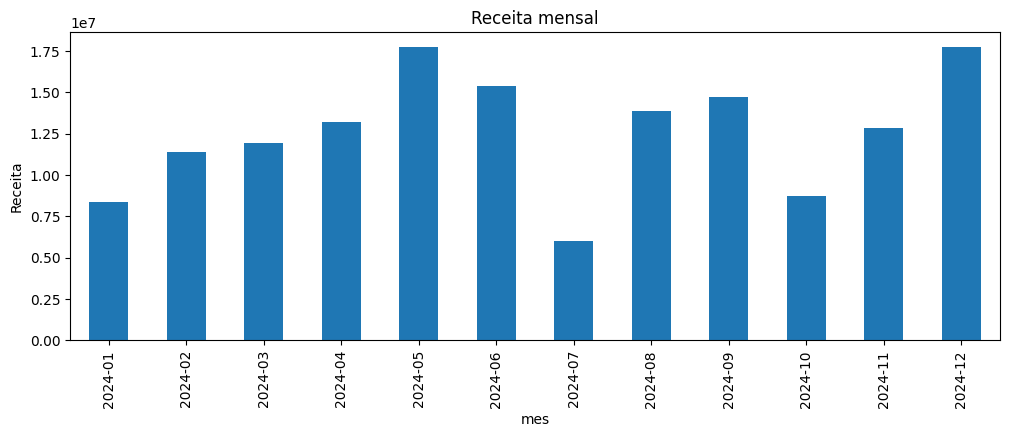

In [33]:
receita_mensal.plot(kind='bar', figsize=(12,4), title='Receita mensal')
plt.ylabel('Receita')
plt.show()

## 14. A última milha: interpretação

Na aula, vimos que um analista não entrega apenas tabela — entrega **decisão**.

### Questão 12
Com base nos resultados do notebook, escreva interpretações gerenciais para:
1. O produto mais lucrativo

R: A decisão mais coerente seria maior investimento em estoque e propagando do item mais lucrativo

2. O estado com maior receita

R:Possibilitar maior disponibilidade de entrega para o estado com maior numero de vendas

3. O canal com maior lucro

R: Direcionar mais funcionarios para o atendimento no canal de E-commerce

4. Um possível problema de qualidade encontrado

A webcam HD apresenta um numero de vendas muito inferior quando comparada aos outros periféricos, portando é necessário repensar a nova compra de estoque do mesmo e buscar um sbstituto de melhor qualidade
